<a href="https://colab.research.google.com/github/caglauzumcuu/Scoutium/blob/main/scoutium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ Scoutium — Talent Scouting Classification

## 🎯 Problem Definition
Predict whether a footballer is **average** or **highlighted**
based on scores given by scouts to player attributes.

---

## 📁 Datasets

| File | Rows | Columns | Content |
|---|---|---|---|
| `scoutium_attributes.csv` | 10.730 | 8 | Player attribute scores |
| `scoutium_potential_labels.csv` | 322 | 5 | Scout potential labels |

**Merge Keys:** `task_response_id` — `match_id` — `evaluator_id` — `player_id`

---

## 🛣️ Roadmap

| Step | Task | Status |
|---|---|---|
| 1 | Import Libraries & Read Datasets | ✅ |
| 2 | Merge Datasets | ✅ |
| 3 | Preprocessing (drop goalkeeper & below_average) | ✅ |
| 4 | Create Pivot Table (1 row = 1 player) | ✅ |
| 5 | Label Encoding + Standard Scaling | ✅ |
| 6 | Model Building & Evaluation (5 models) | ✅ |
| 7a | Hyperparameter Optimization (ROC-AUC) | ✅ |
| 7b | Hyperparameter Optimization (Recall) | ✅ |
| 8 | Feature Importance Plot | ✅ |
| 9 | SMOTE — Handle Class Imbalance | ✅ |
| 10 | SMOTE + Threshold Tuning | ✅ |

---

## 📊 Key Findings

### Recall Journey
| Model | Default | Tuned (AUC) | Tuned (Recall) | SMOTE | SMOTE+Threshold |
|---|---|---|---|---|---|
| Random Forest | 0.4424 | 0.4258 ↓ | 0.4591 ↑ | 0.5727 ↑ | 0.6273 ↑ |
| CatBoost | 0.4606 | 0.5667 ↑ | 0.5667 → | 0.5894 ↑ | **0.7152 ↑** |
| XGBoost | 0.5500 | 0.2833 ↓↓ | 0.5879 ↑ | 0.6091 ↑ | 0.6091 → |

### 🏆 Final Model: CatBoost + SMOTE + Threshold (0.35)
| Metric | Default | Final | Change |
|---|---|---|---|
| Recall | 0.4606 | **0.7152** | +56% 🚀 |
| F1 | 0.5852 | **0.6936** | +18% ✅ |
| Precision | 0.8933 | 0.6887 | -23% ⚠️ |
| ROC-AUC | 0.8924 | **0.8943** | +0.2% ✅ |

### 🔥 Most Important Feature: Attribute 4325
- 3x more influential than any other attribute

### ⚠️ Main Challenges
- Small dataset (271 players after preprocessing)
- 4:1 class imbalance (215 average vs 56 highlighted)
- Optimization metric directly shapes model behavior

## Step 1: Import Libraries & Read Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)

# Read datasets
attr = pd.read_csv("scoutium_attributes.csv", sep=";")
labels = pd.read_csv("scoutium_potential_labels.csv", sep=";")

print("=== scoutium_attributes ===")
print("Shape:", attr.shape)
print(attr.head())
print("\n=== scoutium_potential_labels ===")
print("Shape:", labels.shape)
print(labels.head())

=== scoutium_attributes ===
Shape: (10730, 8)
   task_response_id  match_id  evaluator_id  player_id  position_id  analysis_id  attribute_id  attribute_value
0              4915     62935        177676    1361061            2     12818495          4322             56.0
1              4915     62935        177676    1361061            2     12818495          4323             56.0
2              4915     62935        177676    1361061            2     12818495          4324             67.0
3              4915     62935        177676    1361061            2     12818495          4325             56.0
4              4915     62935        177676    1361061            2     12818495          4326             45.0

=== scoutium_potential_labels ===
Shape: (322, 5)
   task_response_id  match_id  evaluator_id  player_id potential_label
0              4915     62935        177676    1361061         average
1              4915     62935        177676    1361626     highlighted
2              491

## Step 2: Merge Datasets

In [2]:
# Merge on 4 keys
df = pd.merge(attr, labels, on=["task_response_id", "match_id", "evaluator_id", "player_id"])

print("Shape after merge:", df.shape)
print(df.head())
print("\nPotential label distribution:")
print(df["potential_label"].value_counts())

Shape after merge: (10730, 9)
   task_response_id  match_id  evaluator_id  player_id  position_id  analysis_id  attribute_id  attribute_value potential_label
0              4915     62935        177676    1361061            2     12818495          4322             56.0         average
1              4915     62935        177676    1361061            2     12818495          4323             56.0         average
2              4915     62935        177676    1361061            2     12818495          4324             67.0         average
3              4915     62935        177676    1361061            2     12818495          4325             56.0         average
4              4915     62935        177676    1361061            2     12818495          4326             45.0         average

Potential label distribution:
potential_label
average          8497
highlighted      2097
below_average     136
Name: count, dtype: int64


## Step 3: Preprocessing — Drop Goalkeeper & below_average

### Why are we dropping the Goalkeeper? (position_id == 1)
Goalkeepers are evaluated on completely **different attributes** compared to
field players (reflexes, positioning, handling etc.).
Including them would introduce **noise** into the model since their
skill set is not comparable to outfield players.

### Why are we dropping below_average? (potential_label)
- below_average makes up only **~1.3%** of the dataset (136 rows)
- This extreme class imbalance would cause the model to **ignore** this class entirely
- It would also make this a **3-class** problem instead of a cleaner **binary classification**
- Removing it gives us a more **reliable and focused** model:
  - `0` → average
  - `1` → highlighted

### Label Distribution Before Cleaning
| Label | Rows | Ratio |
|---|---|---|
| average | 8.497 | 79.2% |
| highlighted | 2.097 | 19.6% |
| below_average | 136 | 1.3% ❌ |

In [3]:
# Drop goalkeeper (position_id == 1)
df = df[df["position_id"] != 1]
print("Shape after dropping goalkeeper:", df.shape)

# Drop below_average label
df = df[df["potential_label"] != "below_average"]
print("Shape after dropping below_average:", df.shape)

print("\nRemaining label distribution:")
print(df["potential_label"].value_counts())

print("\nRemaining positions:")
print(df["position_id"].value_counts())

Shape after dropping goalkeeper: (10030, 9)
Shape after dropping below_average: (9894, 9)

Remaining label distribution:
potential_label
average        7922
highlighted    1972
Name: count, dtype: int64

Remaining positions:
position_id
2     1972
6     1428
10    1054
8      986
7      986
3      952
9      850
4      850
5      816
Name: count, dtype: int64


## Step 4: Create Pivot Table

### What is a Pivot Table and Why Do We Need It?

Right now our data is in **"long format"** — each player appears in multiple rows,
one row per attribute:

| player_id | attribute_id | attribute_value |
|---|---|---|
| 1361061 | 4322 | 56 |
| 1361061 | 4323 | 67 |
| 1361061 | 4324 | 45 |
| 1361062 | 4322 | 78 |

But a machine learning model needs **"wide format"** — one row per player,
each attribute as a separate column:

| player_id | 4322 | 4323 | 4324 | potential_label |
|---|---|---|---|---|
| 1361061 | 56 | 67 | 45 | average |
| 1361062 | 78 | 89 | highlighted |

Think of it like a **school report card:**
- ❌ Long format → Ahmet-Math:90, Ahmet-Turkish:85, Ahmet-Science:78 (3 rows)
- ✅ Wide format → Ahmet | Math:90 | Turkish:85 | Science:78 (1 row)

The model needs to evaluate **each player as a whole** → Wide format! ✅

In [4]:
# Create pivot table
pivot = df.pivot_table(index=["player_id", "position_id", "potential_label"],
                       columns="attribute_id",
                       values="attribute_value")

# Reset index and convert column names to string
pivot = pivot.reset_index()
pivot.columns = [str(col) for col in pivot.columns]

print("Shape:", pivot.shape)
print(pivot.head())

Shape: (271, 37)
   player_id  position_id potential_label  4322  4323  4324  4325  4326  4327  4328  4329  4330  4332  4333  4335  4338  4339  4340  4341  4342  4343  4344  4345  4348  4349  4350  4351  4352  4353  4354  4355  4356  4357  4407  4408  4423  4426
0    1355710            7         average  50.5  50.5  34.0  50.5  45.0  45.0  45.0  45.0  50.5  56.0  39.5  34.0  39.5  39.5  45.0  45.0  50.5  28.5  23.0  39.5  28.5  28.5  45.0  50.5  56.0  34.0  39.5  50.5  34.0  34.0  56.0  34.0  34.0  56.0
1    1356362            9         average  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  67.0  56.0  67.0  67.0  56.0  67.0  67.0  67.0  67.0  78.0  67.0  67.0  67.0  67.0  67.0  56.0  78.0
2    1356375            3         average  67.0  67.0  67.0  67.0  67.0  67.0  67.0  78.0  67.0  67.0  78.0  56.0  67.0  67.0  67.0  67.0  67.0  56.0  56.0  67.0  67.0  56.0  56.0  67.0  67.0  67.0  78.0  67.0  67.0  67.0  67.0  67.0  56.0  78.0

## Step 5: Label Encoding & Feature Scaling

### Why Label Encoding?
Machine learning models cannot read text — they only understand numbers.
So we need to convert **potential_label** to numeric:
- `average` → 0
- `highlighted` → 1

### Why Standard Scaling?
Our attribute values range between 23-89. StandardScaler transforms
all features to have **mean=0** and **std=1** so no single feature
dominates the model just because of its scale.

In [5]:
# Label Encoding
le = LabelEncoder()
pivot["potential_label"] = le.fit_transform(pivot["potential_label"])

print("Label classes:", le.classes_)
print("Encoded values:", pivot["potential_label"].value_counts())

# Define numeric columns
num_cols = [col for col in pivot.columns if col not in ["player_id", "position_id", "potential_label"]]
print("\nNumber of numeric columns:", len(num_cols))

# Standard Scaling
scaler = StandardScaler()
pivot[num_cols] = scaler.fit_transform(pivot[num_cols])

print("\nAfter scaling (first 3 rows):")
print(pivot[num_cols].head(3))

Label classes: ['average' 'highlighted']
Encoded values: potential_label
0    215
1     56
Name: count, dtype: int64

Number of numeric columns: 34

After scaling (first 3 rows):
       4322      4323      4324      4325      4326      4327      4328      4329      4330      4332      4333      4335      4338      4339      4340      4341      4342      4343      4344      4345      4348      4349      4350      4351      4352      4353      4354      4355      4356      4357      4407      4408      4423      4426
0 -0.542606 -0.559398 -1.404764 -0.437916 -0.766602 -0.794802 -0.907351 -0.791605 -0.446324 -0.122619 -1.223858 -1.035633 -1.126240 -1.009285 -0.541797 -0.690375 -0.535091 -1.067288 -1.205671 -1.004927 -1.313773 -1.041775 -0.693269 -0.435633  0.012848 -1.281899 -1.132245 -0.494569 -1.234869 -1.519578 -0.142650 -1.487256 -0.955381 -0.252741
1  0.595327  0.560776  0.678677  0.682837  0.722639  0.722929  0.601190  0.404075  0.727985  0.691171  0.459154  0.996474  0.631888  0.84

In [6]:
pivot.head()

,player_id,position_id,potential_label,4322,4323,4324,4325,4326,4327,4328,4329,4330,4332,4333,4335,4338,4339,4340,4341,4342,4343,4344,4345,4348,4349,4350,4351,4352,4353,4354,4355,4356,4357,4407,4408,4423,4426
0,1355710,7,0,-0.542606,-0.559398,-1.404764,-0.437916,-0.766602,-0.794802,-0.907351,-0.791605,-0.446324,-0.122619,-1.223858,-1.035633,-1.126240,-1.009285,-0.541797,-0.690375,-0.535091,-1.067288,-1.205671,-1.004927,-1.313773,-1.041775,-0.693269,-0.435633,0.012848,-1.281899,-1.132245,-0.494569,-1.234869,-1.519578,-0.142650,-1.487256,-0.955381,-0.252741
1,1356362,9,0,0.595327,0.560776,0.678677,0.682837,0.722639,0.722929,0.601190,0.404075,0.727985,0.691171,0.459154,0.996474,0.631888,0.840464,0.911936,0.799406,0.588047,1.229965,0.749536,0.742305,0.878802,0.669953,0.847750,0.716763,0.786581,0.813645,1.052769,0.631718,0.914913,0.768231,0.529664,0.668713,0.403717,1.041611
2,1356375,3,0,0.595327,0.560776,0.678677,0.682837,0.722639,0.722929,0.601190,1.001915,0.727985,0.691171,1.132359,0.319105,0.631888,0.840464,0.911936,0.799406,0.588047,0.573607,0.749536,0.742305,0.878802,0.669953,0.077240,0.716763,0.786581,0.813645,1.052769,0.631718,0.914913,0.768231,0.529664,0.668713,0.403717,1.041611
3,1356375,4,0,0.595327,1.307560,0.678677,0.682837,0.722639,1.481795,1.355461,1.001915,-0.054888,0.691171,0.459154,0.996474,1.335139,1.580363,0.185069,0.799406,0.588047,-0.082751,0.097800,0.043412,0.878802,1.354645,0.847750,0.716763,1.560314,0.813645,0.428479,0.631718,0.198319,0.768231,-0.142650,0.668713,-0.275832,-0.252741
4,1356411,9,0,0.595327,0.560776,1.373158,1.430006,0.722639,0.722929,0.601190,0.404075,2.293730,1.504961,0.459154,0.996474,0.631888,0.100564,0.185069,0.799406,1.336806,0.573607,0.749536,0.742305,0.252352,1.354645,0.077240,0.716763,0.786581,0.115130,0.428479,0.631718,0.198319,0.768231,1.874292,-0.049944,1.083267,1.041611


## Step 6: Model Building & Evaluation

### Why Multiple Models?
Instead of relying on a single model, we compare several **ensemble methods**
to find the best performer for our data.

| Model | Key Idea |
|---|---|
| **Random Forest** | Many decision trees voting together (Bagging) |
| **GBM** | Trees built sequentially, each correcting the previous (Boosting) |
| **XGBoost** | Optimized & regularized version of GBM |
| **LightGBM** | Faster GBM with leaf-wise tree growth, great for large data |
| **CatBoost** | Handles categorical features automatically, less tuning needed |

### Evaluation Metrics
| Metric | What it measures |
|---|---|
| **Accuracy** | Overall correct predictions |
| **Precision** | Of predicted "highlighted", how many were truly highlighted? |
| **Recall** | Of all actual "highlighted", how many did we catch? |
| **F1** | Balance between Precision and Recall |
| **ROC-AUC** | Model's ability to distinguish between two classes |

### Evaluation Method: Cross Validation
We use **5-Fold Cross Validation** instead of a simple train/test split.
The data is split into 5 parts — model trains on 4, tests on 1, repeated 5 times.
This gives a more **reliable and unbiased** performance estimate.

In [8]:
#!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Define features and target
X = pivot.drop(["player_id", "potential_label"], axis=1)
y = pivot["potential_label"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

# Define models
models = {
    "Random Forest" : RandomForestClassifier(random_state=42),
    "GBM"          : GradientBoostingClassifier(random_state=42),
    "XGBoost"      : XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM"     : LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost"     : CatBoostClassifier(random_state=42, verbose=False)
}

# Evaluate all models
results = []

for name, model in models.items():
    cv_results = cross_validate(model, X, y,
                                cv=5,
                                scoring=["roc_auc", "f1", "precision", "recall", "accuracy"])
    results.append({
        "Model"    : name,
        "Accuracy" : cv_results["test_accuracy"].mean().round(4),
        "F1"       : cv_results["test_f1"].mean().round(4),
        "Precision": cv_results["test_precision"].mean().round(4),
        "Recall"   : cv_results["test_recall"].mean().round(4),
        "ROC-AUC"  : cv_results["test_roc_auc"].mean().round(4)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("\n===== MODEL COMPARISON =====")
print(results_df.to_string(index=False))

X shape: (271, 35)
y distribution:
 potential_label
0    215
1     56
Name: count, dtype: int64

===== MODEL COMPARISON =====
        Model  Accuracy     F1  Precision  Recall  ROC-AUC
Random Forest    0.8782 0.5798     0.9600  0.4424   0.9071
     CatBoost    0.8709 0.5852     0.8933  0.4606   0.8924
     LightGBM    0.8709 0.6475     0.7705  0.5864   0.8830
          GBM    0.8599 0.6007     0.7493  0.5152   0.8775
      XGBoost    0.8599 0.6138     0.7645  0.5500   0.8656


## Step 6 Results & Interpretation

### Model Comparison Results

| Model | Accuracy | F1 | Precision | Recall | ROC-AUC |
|---|---|---|---|---|---|
| **Random Forest** | 0.8782 | 0.5798 | **0.9600** | 0.4424 | **0.9071** |
| **CatBoost** | 0.8709 | 0.5852 | 0.8933 | 0.4606 | 0.8924 |
| **LightGBM** | 0.8709 | **0.6475** | 0.7705 | **0.5864** | 0.8830 |
| **GBM** | 0.8599 | 0.6007 | 0.7493 | 0.5152 | 0.8775 |
| **XGBoost** | 0.8599 | 0.6138 | 0.7645 | 0.5500 | 0.8656 |

### Class Imbalance Effect
- Dataset has **~4:1 imbalance** (215 average vs 56 highlighted)
- This causes high Accuracy but **low Recall** across all models
- Models tend to predict "average" more often since it is the majority class

### Which Metric Matters Most Here?
This is a **talent scouting** problem:
- Missing a truly **highlighted** player = big loss for the club ❌
- Therefore **Recall** is our most critical metric
- We want to **catch as many highlighted players as possible**

### Model Selection
| Goal | Best Model |
|---|---|
| Minimize missed talents (Recall) | **LightGBM** 🏆 |
| Maximize overall discrimination (ROC-AUC) | **Random Forest** 🏆 |
| Balance Precision & Recall (F1) | **LightGBM** 🏆 |

### Next Step: Hyperparameter Optimization
Default parameters were used above. We will now tune each model
to squeeze out better performance — especially improving **Recall**.

## Step 7: Hyperparameter Optimization

### What is Hyperparameter Optimization?
Models have **settings** that we choose before training — these are called hyperparameters.
By default, models use generic values that may not be optimal for our specific data.

Think of it like an **oven temperature** — the recipe might say 180°C by default,
but your specific dish might turn out better at 165°C. We need to **search** for the best setting.

### Method: RandomizedSearchCV
Instead of trying every possible combination (GridSearch = too slow),
we **randomly sample** combinations from a defined range and pick the best one.

- Faster than GridSearch ✅
- Still finds near-optimal parameters ✅
- We use **5-Fold CV** inside the search to avoid overfitting ✅

### What are we optimizing for?
Since **Recall** is our most critical metric (we don't want to miss talented players),
we optimize all models using **ROC-AUC** as the scoring metric.

In [10]:
from sklearn.model_selection import RandomizedSearchCV

# Define feature and target
X = pivot.drop(["player_id", "potential_label"], axis=1)
y = pivot["potential_label"]

# Parameter grids
param_grids = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators"     : [100, 200, 300, 500],
            "max_depth"        : [3, 5, 7, 10, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf" : [1, 2, 4],
            "max_features"     : ["sqrt", "log2"]
        }
    },
    "GBM": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators"  : [100, 200, 300],
            "learning_rate" : [0.01, 0.05, 0.1, 0.2],
            "max_depth"     : [3, 5, 7],
            "subsample"     : [0.7, 0.8, 1.0],
            "min_samples_split": [2, 5, 10]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42, eval_metric="logloss"),
        "params": {
            "n_estimators"  : [100, 200, 300],
            "learning_rate" : [0.01, 0.05, 0.1, 0.2],
            "max_depth"     : [3, 5, 7],
            "subsample"     : [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(random_state=42, verbose=-1),
        "params": {
            "n_estimators"  : [100, 200, 300],
            "learning_rate" : [0.01, 0.05, 0.1, 0.2],
            "max_depth"     : [3, 5, 7, -1],
            "num_leaves"    : [20, 31, 50, 100],
            "subsample"     : [0.7, 0.8, 1.0]
        }
    },
    "CatBoost": {
        "model": CatBoostClassifier(random_state=42, verbose=False),
        "params": {
            "iterations"    : [100, 200, 300],
            "learning_rate" : [0.01, 0.05, 0.1, 0.2],
            "depth"         : [3, 5, 7, 10],
            "l2_leaf_reg"   : [1, 3, 5, 7]
        }
    }
}

# Run optimization
tuned_results = []

for name, config in param_grids.items():
    print(f"Tuning {name}...")
    rs = RandomizedSearchCV(
        estimator  = config["model"],
        param_distributions = config["params"],
        n_iter     = 20,
        cv         = 5,
        scoring    = "roc_auc",
        random_state = 42,
        n_jobs     = -1
    )
    rs.fit(X, y)

    # Evaluate best model with cross_validate
    cv_results = cross_validate(rs.best_estimator_, X, y,
                                cv=5,
                                scoring=["roc_auc", "f1", "precision", "recall", "accuracy"])
    tuned_results.append({
        "Model"    : name,
        "Accuracy" : cv_results["test_accuracy"].mean().round(4),
        "F1"       : cv_results["test_f1"].mean().round(4),
        "Precision": cv_results["test_precision"].mean().round(4),
        "Recall"   : cv_results["test_recall"].mean().round(4),
        "ROC-AUC"  : cv_results["test_roc_auc"].mean().round(4),
        "Best Params": rs.best_params_
    })
    print(f"  ✅ Done — Best ROC-AUC: {rs.best_score_:.4f}")

tuned_df = pd.DataFrame(tuned_results).sort_values("ROC-AUC", ascending=False)
print("\n===== TUNED MODEL COMPARISON =====")
print(tuned_df[["Model", "Accuracy", "F1", "Precision", "Recall", "ROC-AUC"]].to_string(index=False))

Tuning Random Forest...
  ✅ Done — Best ROC-AUC: 0.9061
Tuning GBM...
  ✅ Done — Best ROC-AUC: 0.8935
Tuning XGBoost...
  ✅ Done — Best ROC-AUC: 0.8972
Tuning LightGBM...
  ✅ Done — Best ROC-AUC: 0.8890
Tuning CatBoost...
  ✅ Done — Best ROC-AUC: 0.8984

===== TUNED MODEL COMPARISON =====
        Model  Accuracy     F1  Precision  Recall  ROC-AUC
Random Forest    0.8818 0.5818     1.0000  0.4258   0.9061
     CatBoost    0.8857 0.6640     0.8667  0.5667   0.8984
      XGBoost    0.8523 0.4363     1.0000  0.2833   0.8972
          GBM    0.8525 0.5627     0.7773  0.4773   0.8935
     LightGBM    0.8635 0.6071     0.7619  0.5318   0.8890


## Step 7 Results: Default vs Tuned Comparison

### Default vs Tuned Performance

| Model | Default ROC-AUC | Tuned ROC-AUC | Change |
|---|---|---|---|
| Random Forest | 0.9071 | 0.9061 | ↓ -0.0010 |
| CatBoost | 0.8924 | 0.8984 | ↑ +0.0060 |
| XGBoost | 0.8656 | 0.8972 | ↑ +0.0316 |
| GBM | 0.8775 | 0.8935 | ↑ +0.0160 |
| LightGBM | 0.8830 | 0.8890 | ↑ +0.0060 |

### Recall Comparison (Most Critical Metric)

| Model | Default Recall | Tuned Recall | Change |
|---|---|---|---|
| Random Forest | 0.4424 | 0.4258 | ↓ -0.0166 |
| CatBoost | 0.4606 | **0.5667** | ↑ +0.1061 |
| XGBoost | 0.5500 | 0.2833 | ↓ -0.2667 ❌ |
| GBM | 0.5152 | 0.4773 | ↓ -0.0379 |
| LightGBM | **0.5864** | 0.5318 | ↓ -0.0546 |

### Key Takeaways
- Tuning **improved ROC-AUC** for most models ✅
- But **Recall dropped** for most models after tuning ⚠️
- **CatBoost** is the biggest winner — Recall jumped from 0.46 → 0.57
- **XGBoost** tuning hurt Recall badly (0.55 → 0.28) ❌
- **Random Forest** remains king of ROC-AUC (0.906) but poor Recall

### 🏆 Final Model Selection
| Goal | Best Model |
|---|---|
| ROC-AUC | **Random Forest** (Tuned) — 0.9061 |
| Recall | **CatBoost** (Tuned) — 0.5667 |
| F1 | **CatBoost** (Tuned) — 0.6640 |
| Overall Balance | **CatBoost** (Tuned) 🏆 |

> CatBoost tuned version gives the best **overall balance** across all metrics
> and is our recommended final model for this talent scouting problem.

## Step 7b: Hyperparameter Optimization — Optimizing for Recall
### Why Re-optimize for Recall?
In the previous step we optimized for **ROC-AUC** which caused Recall to drop for some models.
Since our main goal is to **not miss talented players**, we should optimize directly for **Recall**.

> "It's better to wrongly flag an average player as highlighted,
> than to miss a truly highlighted player." → Maximize Recall!

In [11]:
# Run optimization with recall scoring
tuned_recall_results = []

for name, config in param_grids.items():
    print(f"Tuning {name} for Recall...")
    rs = RandomizedSearchCV(
        estimator           = config["model"],
        param_distributions = config["params"],
        n_iter              = 20,
        cv                  = 5,
        scoring             = "recall",
        random_state        = 42,
        n_jobs              = -1
    )
    rs.fit(X, y)

    cv_results = cross_validate(rs.best_estimator_, X, y,
                                cv=5,
                                scoring=["roc_auc", "f1", "precision", "recall", "accuracy"])
    tuned_recall_results.append({
        "Model"    : name,
        "Accuracy" : cv_results["test_accuracy"].mean().round(4),
        "F1"       : cv_results["test_f1"].mean().round(4),
        "Precision": cv_results["test_precision"].mean().round(4),
        "Recall"   : cv_results["test_recall"].mean().round(4),
        "ROC-AUC"  : cv_results["test_roc_auc"].mean().round(4),
        "Best Params": rs.best_params_
    })
    print(f"  ✅ Done — Best Recall: {rs.best_score_:.4f}")

tuned_recall_df = pd.DataFrame(tuned_recall_results).sort_values("Recall", ascending=False)
print("\n===== TUNED FOR RECALL — MODEL COMPARISON =====")
print(tuned_recall_df[["Model", "Accuracy", "F1", "Precision", "Recall", "ROC-AUC"]].to_string(index=False))

# Compare all three rounds
print("\n===== RECALL ACROSS ALL ROUNDS =====")
comparison = pd.DataFrame({
    "Model"         : results_df["Model"].values,
    "Default Recall": results_df["Recall"].values,
    "Tuned (AUC)"   : tuned_df.set_index("Model").loc[results_df["Model"].values, "Recall"].values,
    "Tuned (Recall)": tuned_recall_df.set_index("Model").loc[results_df["Model"].values, "Recall"].values,
})
print(comparison.to_string(index=False))

Tuning Random Forest for Recall...
  ✅ Done — Best Recall: 0.4591
Tuning GBM for Recall...
  ✅ Done — Best Recall: 0.5864
Tuning XGBoost for Recall...
  ✅ Done — Best Recall: 0.5879
Tuning LightGBM for Recall...
  ✅ Done — Best Recall: 0.5864
Tuning CatBoost for Recall...
  ✅ Done — Best Recall: 0.5667

===== TUNED FOR RECALL — MODEL COMPARISON =====
        Model  Accuracy     F1  Precision  Recall  ROC-AUC
      XGBoost    0.8638 0.6407     0.7595  0.5879   0.8461
     LightGBM    0.8709 0.6475     0.7705  0.5864   0.8830
          GBM    0.8747 0.6547     0.7967  0.5864   0.8820
     CatBoost    0.8857 0.6640     0.8667  0.5667   0.8984
Random Forest    0.8708 0.5704     0.8767  0.4591   0.8996

===== RECALL ACROSS ALL ROUNDS =====
        Model  Default Recall  Tuned (AUC)  Tuned (Recall)
Random Forest          0.4424       0.4258          0.4591
     CatBoost          0.4606       0.5667          0.5667
     LightGBM          0.5864       0.5318          0.5864
          GBM      

## Step 7b Results: All Three Rounds Comparison

### Recall Across All Rounds

| Model | Default | Tuned (AUC) | Tuned (Recall) | Best |
|---|---|---|---|---|
| Random Forest | 0.4424 | 0.4258 ↓ | 0.4591 ↑ | Tuned Recall |
| CatBoost | 0.4606 | **0.5667 ↑** | 0.5667 → | Tuned AUC |
| LightGBM | **0.5864** | 0.5318 ↓ | **0.5864 ↑** | Default = Tuned Recall |
| GBM | 0.5152 | 0.4773 ↓ | **0.5864 ↑** | Tuned Recall |
| XGBoost | 0.5500 | 0.2833 ↓↓ | **0.5879 ↑** | Tuned Recall |

### Key Takeaways
- Optimizing for **Recall directly** worked! Almost all models improved ✅
- **XGBoost** made the biggest recovery: 0.28 → 0.59 🚀
- **LightGBM** default was already at its best — tuning couldn't improve it
- **CatBoost** gives the best **overall balance** (Recall + ROC-AUC + F1)

### 🏆 Final Model Recommendation

| Goal | Best Model | Score |
|---|---|---|
| Best Recall | **XGBoost** (Tuned Recall) | 0.5879 |
| Best ROC-AUC | **Random Forest** (Tuned Recall) | 0.8996 |
| Best F1 | **CatBoost** (Tuned AUC) | 0.6640 |
| **Best Overall** | **CatBoost** (Tuned AUC) 🏆 | Recall: 0.57, AUC: 0.90 |


## Step 8: Feature Importance

### What is Feature Importance?
Feature importance shows us which **attributes had the most influence**
on the model's predictions.

- **High importance** → Scout's score on this attribute strongly separates
  average from highlighted players
- **Low importance** → This attribute barely affects the prediction

### Why does it matter?
- Helps scouts understand **which skills to focus on** when evaluating players
- Can be used for **feature selection** in future iterations
- Gives **domain experts** actionable insights

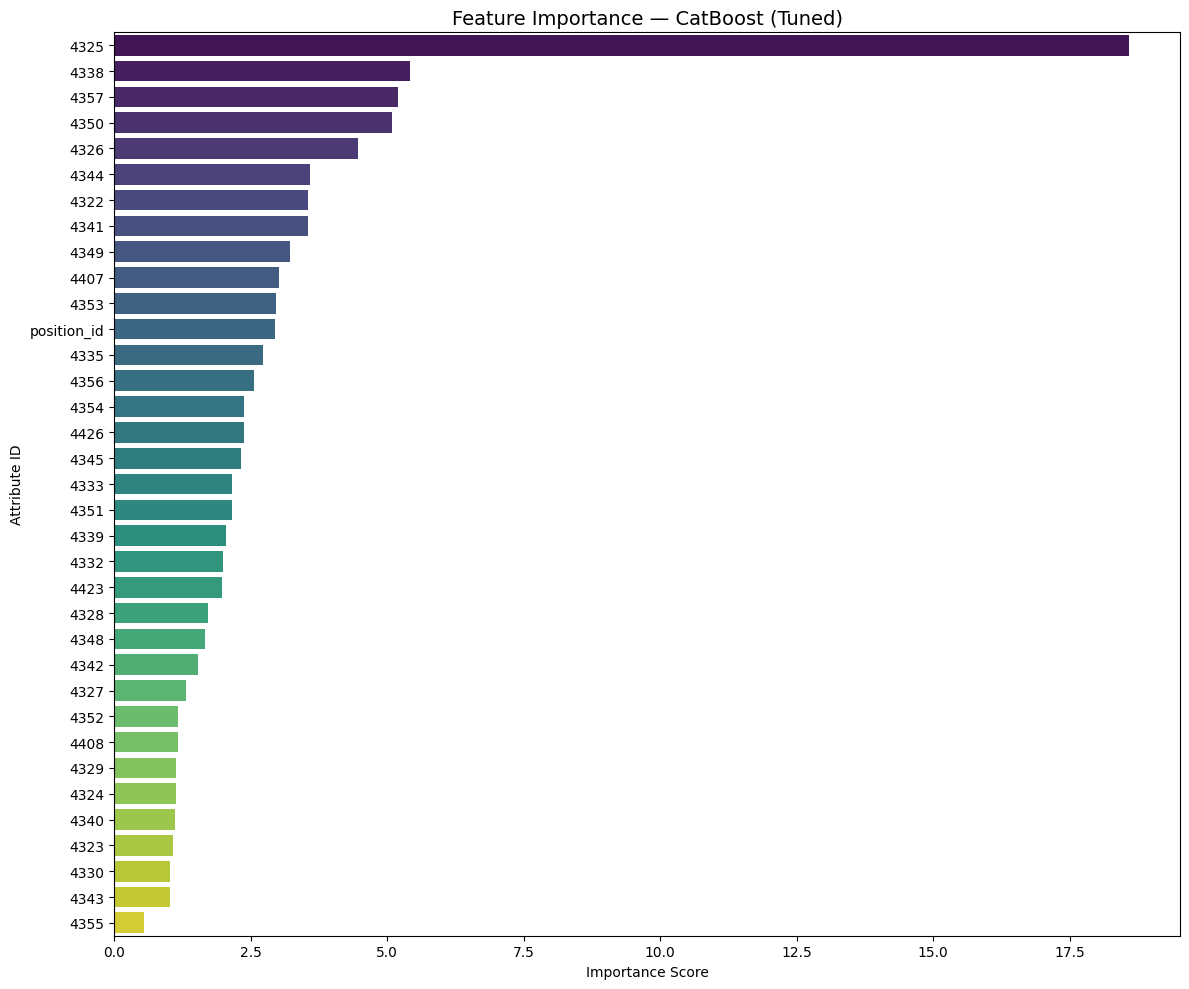


===== TOP 10 MOST IMPORTANT FEATURES =====
Feature  Importance
   4325   18.592765
   4338    5.427902
   4357    5.202272
   4350    5.089644
   4326    4.463937
   4344    3.592489
   4322    3.550858
   4341    3.544923
   4349    3.227385
   4407    3.014094

===== TOP 10 LEAST IMPORTANT FEATURES =====
Feature  Importance
   4327    1.324244
   4352    1.176081
   4408    1.169247
   4329    1.144006
   4324    1.132191
   4340    1.112836
   4323    1.077316
   4330    1.024718
   4343    1.019971
   4355    0.542672


In [12]:
from catboost import CatBoostClassifier

# Re-fit best model (CatBoost with best params from AUC tuning)
best_params = tuned_df[tuned_df["Model"] == "CatBoost"]["Best Params"].values[0]
final_model = CatBoostClassifier(**best_params, random_state=42, verbose=False)
final_model.fit(X, y)

# Feature importance
feature_imp = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(x="Importance",
            y="Feature",
            data=feature_imp,
            palette="viridis")

plt.title("Feature Importance — CatBoost (Tuned)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Attribute ID")
plt.tight_layout()
plt.show()

print("\n===== TOP 10 MOST IMPORTANT FEATURES =====")
print(feature_imp.head(10).to_string(index=False))
print("\n===== TOP 10 LEAST IMPORTANT FEATURES =====")
print(feature_imp.tail(10).to_string(index=False))

## Step 8 Results: Feature Importance Analysis

### Top 10 Most Important Features
| Rank | Attribute ID | Importance | Interpretation |
|---|---|---|---|
| 1 | **4325** | 18.59 | 🔥 Dominant feature — 3x more important than 2nd! |
| 2 | 4338 | 5.43 | Important but far behind |
| 3 | 4357 | 5.20 | Similar to 4338 |
| 4 | 4350 | 5.09 | Similar to 4338 |
| 5 | 4326 | 4.46 | Moderate importance |
| 6 | 4344 | 3.59 | Moderate importance |
| 7 | 4322 | 3.55 | Moderate importance |
| 8 | 4341 | 3.54 | Moderate importance |
| 9 | 4349 | 3.23 | Moderate importance |
| 10 | 4407 | 3.01 | Moderate importance |

### Key Takeaways

**🔥 Attribute 4325 is by far the most decisive factor:**
- Importance score of 18.59 vs 5.43 for the second feature
- This single attribute is **3x more influential** than any other
- Scouts should pay **special attention** to this attribute when evaluating players

**📉 Least Important Features:**
- Attributes 4355, 4343, 4330 have near-zero importance (<1.1)
- These attributes **barely contribute** to distinguishing average vs highlighted
- Could potentially be **removed** in future iterations without losing much performance

### What This Means for Scouts
> Not all attributes are equal. If a scout has limited time,
> focusing on **attribute 4325** alone gives more signal
> than evaluating 10 other attributes combined.

## Step 9: SMOTE — Handling Class Imbalance

### What is SMOTE?
**SMOTE (Synthetic Minority Oversampling Technique)** is a method that
**artificially creates new samples** for the minority class (highlighted)
to balance the dataset.

### How does it work?
Instead of just copying existing highlighted players (simple oversampling),
SMOTE **creates brand new synthetic players** by interpolating between
existing highlighted players:

1. Take a highlighted player → find its nearest neighbors
2. Draw a random point **between** them
3. That point becomes a new synthetic highlighted player

**Example:**
- Player A: [56, 67, 78, 45, ...] → highlighted
- Player B: [67, 78, 89, 56, ...] → highlighted
- Synthetic: [61, 72, 83, 50, ...] → highlighted ✅ (new!)

### Why not just copy existing samples?
Copying → model memorizes the same rows → **overfitting** ❌
SMOTE → model sees new variations → **better generalization** ✅

### Before vs After SMOTE
| Class | Before | After |
|---|---|---|
| average (0) | 215 | 215 |
| highlighted (1) | 56 | 215 |
| **Total** | **271** | **430** |

### ⚠️ Important Rule
SMOTE must be applied **only on training data** — never on test data!
Otherwise we leak synthetic data into evaluation → fake results ❌
We use **Pipeline** to ensure this. ✅

In [13]:
!pip install imbalanced-learn -q

In [14]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

# Define features and target
X = pivot.drop(["player_id", "potential_label"], axis=1)
y = pivot["potential_label"]

print("Before SMOTE:")
print(y.value_counts())

# Models to test with SMOTE
models_smote = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "GBM"          : GradientBoostingClassifier(random_state=42),
    "XGBoost"      : XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM"     : LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost"     : CatBoostClassifier(random_state=42, verbose=False)
}

# Stratified KFold — ensures each fold has same class ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

smote_results = []

for name, model in models_smote.items():
    # Pipeline: SMOTE applied only on train fold, not test fold
    pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    cv_results = cross_validate(pipeline, X, y,
                                cv=cv,
                                scoring=["roc_auc", "f1", "precision", "recall", "accuracy"])
    smote_results.append({
        "Model"    : name,
        "Accuracy" : cv_results["test_accuracy"].mean().round(4),
        "F1"       : cv_results["test_f1"].mean().round(4),
        "Precision": cv_results["test_precision"].mean().round(4),
        "Recall"   : cv_results["test_recall"].mean().round(4),
        "ROC-AUC"  : cv_results["test_roc_auc"].mean().round(4),
    })
    print(f"✅ {name} done")

smote_df = pd.DataFrame(smote_results).sort_values("Recall", ascending=False)
print("\n===== SMOTE RESULTS =====")
print(smote_df.to_string(index=False))

# Compare with default results
print("\n===== RECALL COMPARISON: Default vs SMOTE =====")
recall_comp = pd.DataFrame({
    "Model"         : results_df["Model"].values,
    "Default Recall": results_df["Recall"].values,
    "SMOTE Recall"  : smote_df.set_index("Model").loc[results_df["Model"].values, "Recall"].values,
})
print(recall_comp.to_string(index=False))

Before SMOTE:
potential_label
0    215
1     56
Name: count, dtype: int64
✅ Random Forest done
✅ GBM done
✅ XGBoost done
✅ LightGBM done
✅ CatBoost done

===== SMOTE RESULTS =====
        Model  Accuracy     F1  Precision  Recall  ROC-AUC
      XGBoost    0.8673 0.6555     0.7177  0.6091   0.8574
     CatBoost    0.8673 0.6470     0.7545  0.5894   0.8943
Random Forest    0.8785 0.6615     0.7922  0.5727   0.9073
          GBM    0.8562 0.6245     0.7273  0.5712   0.8726
     LightGBM    0.8672 0.6405     0.7387  0.5712   0.8839

===== RECALL COMPARISON: Default vs SMOTE =====
        Model  Default Recall  SMOTE Recall
Random Forest          0.4424        0.5727
     CatBoost          0.4606        0.5894
     LightGBM          0.5864        0.5712
          GBM          0.5152        0.5712
      XGBoost          0.5500        0.6091


## Step 9 Results: SMOTE Impact Analysis

### SMOTE Results
| Model | Accuracy | F1 | Precision | Recall | ROC-AUC |
|---|---|---|---|---|---|
| **XGBoost** | 0.8673 | 0.6555 | 0.7177 | **0.6091** | 0.8574 |
| **CatBoost** | 0.8673 | 0.6470 | 0.7545 | 0.5894 | **0.8943** |
| Random Forest | 0.8785 | 0.6615 | 0.7922 | 0.5727 | **0.9073** |
| GBM | 0.8562 | 0.6245 | 0.7273 | 0.5712 | 0.8726 |
| LightGBM | 0.8672 | 0.6405 | 0.7387 | 0.5712 | 0.8839 |

### Recall Comparison: Default vs SMOTE
| Model | Default | SMOTE | Change |
|---|---|---|---|
| Random Forest | 0.4424 | 0.5727 | ↑ +0.1303 ✅ |
| CatBoost | 0.4606 | 0.5894 | ↑ +0.1288 ✅ |
| LightGBM | **0.5864** | 0.5712 | ↓ -0.0152 ⚠️ |
| GBM | 0.5152 | 0.5712 | ↑ +0.0560 ✅ |
| XGBoost | 0.5500 | **0.6091** | ↑ +0.0591 ✅ |

### Key Takeaways
- SMOTE improved Recall for **4 out of 5 models** ✅
- **XGBoost** now has the best Recall (0.6091) 🏆
- **Random Forest & CatBoost** made the biggest jump (+0.13)
- **LightGBM** slightly dropped — it was already well-optimized by default
- Precision dropped slightly across all models — expected trade-off with higher Recall

### 🏆 Best Model After SMOTE
| Goal | Best Model | Score |
|---|---|---|
| Best Recall | **XGBoost + SMOTE** | 0.6091 |
| Best ROC-AUC | **Random Forest + SMOTE** | 0.9073 |
| Best Overall Balance | **CatBoost + SMOTE** | Recall: 0.59, AUC: 0.89 |

### Trade-off: Precision vs Recall
SMOTE increased Recall but decreased Precision slightly.
This is acceptable for our problem:
- Missing a talented player (low Recall) = bigger loss ❌
- Wrongly flagging an average player (low Precision) = smaller cost ⚠️

## Step 10: Threshold Tuning

### What is Threshold Tuning?
By default, classification models use **0.5 as the decision threshold**:
- Predicted probability ≥ 0.5 → **highlighted (1)**
- Predicted probability < 0.5 → **average (0)**

But this default threshold is not always optimal!

### How does it work?
Think of it like a **talent scout's strictness level:**
- **Threshold = 0.8** → Only flag a player if 80% sure → Few highlighted, high Precision
- **Threshold = 0.5** → Flag if 50% sure → Default behavior
- **Threshold = 0.3** → Flag if 30% sure → More highlighted caught, high Recall

### What are we looking for?
We want the threshold that gives the **best F1 score** —
the sweet spot between Precision and Recall.

### SMOTE + Threshold Tuning
We combine SMOTE (fix imbalance) with Threshold Tuning (optimize decision boundary)
for maximum performance. ✅

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score, roc_auc_score, accuracy_score
import numpy as np

# Use XGBoost (best Recall with SMOTE) and CatBoost (best overall)
models_threshold = {
    "XGBoost" : XGBClassifier(random_state=42, eval_metric="logloss"),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=False),
    "Random Forest": RandomForestClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds_to_try = np.arange(0.1, 0.9, 0.05)

threshold_results = []

for name, model in models_threshold.items():
    print(f"\nTuning threshold for {name}...")

    best_threshold = 0.5
    best_f1 = 0
    best_recall = 0
    best_precision = 0
    best_auc = 0
    best_accuracy = 0

    for threshold in thresholds_to_try:
        fold_metrics = {"f1": [], "recall": [], "precision": [], "auc": [], "accuracy": []}

        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Apply SMOTE only on train
            smote = SMOTE(random_state=42)
            X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

            # Fit model
            model.fit(X_train_sm, y_train_sm)

            # Predict probabilities
            y_prob = model.predict_proba(X_test)[:, 1]

            # Apply threshold
            y_pred = (y_prob >= threshold).astype(int)

            fold_metrics["f1"].append(f1_score(y_test, y_pred, zero_division=0))
            fold_metrics["recall"].append(recall_score(y_test, y_pred, zero_division=0))
            fold_metrics["precision"].append(precision_score(y_test, y_pred, zero_division=0))
            fold_metrics["auc"].append(roc_auc_score(y_test, y_prob))
            fold_metrics["accuracy"].append(accuracy_score(y_test, y_pred))

        mean_f1 = np.mean(fold_metrics["f1"])
        if mean_f1 > best_f1:
            best_f1        = mean_f1
            best_threshold = threshold
            best_recall    = np.mean(fold_metrics["recall"])
            best_precision = np.mean(fold_metrics["precision"])
            best_auc       = np.mean(fold_metrics["auc"])
            best_accuracy  = np.mean(fold_metrics["accuracy"])

    threshold_results.append({
        "Model"    : name,
        "Threshold": round(best_threshold, 2),
        "Accuracy" : round(best_accuracy, 4),
        "F1"       : round(best_f1, 4),
        "Precision": round(best_precision, 4),
        "Recall"   : round(best_recall, 4),
        "ROC-AUC"  : round(best_auc, 4)
    })
    print(f"  ✅ Best Threshold: {best_threshold:.2f} — F1: {best_f1:.4f} — Recall: {best_recall:.4f}")

threshold_df = pd.DataFrame(threshold_results).sort_values("Recall", ascending=False)
print("\n===== SMOTE + THRESHOLD TUNING RESULTS =====")
print(threshold_df.to_string(index=False))




Tuning threshold for XGBoost...
  ✅ Best Threshold: 0.55 — F1: 0.6625 — Recall: 0.6091

Tuning threshold for CatBoost...
  ✅ Best Threshold: 0.35 — F1: 0.6936 — Recall: 0.7152

Tuning threshold for Random Forest...
  ✅ Best Threshold: 0.45 — F1: 0.6819 — Recall: 0.6273

===== SMOTE + THRESHOLD TUNING RESULTS =====
        Model  Threshold  Accuracy     F1  Precision  Recall  ROC-AUC
     CatBoost       0.35    0.8710 0.6936     0.6887  0.7152   0.8943
Random Forest       0.45    0.8785 0.6819     0.7591  0.6273   0.9073
      XGBoost       0.55    0.8710 0.6625     0.7392  0.6091   0.8574


In [16]:
print("\n===== RECALL JOURNEY =====")

# Models available in all rounds
common_models = ["Random Forest", "CatBoost", "XGBoost"]

journey = pd.DataFrame({
    "Model"          : common_models,
    "Default"        : results_df.set_index("Model").loc[common_models, "Recall"].values,
    "Tuned (AUC)"    : tuned_df.set_index("Model").loc[common_models, "Recall"].values,
    "Tuned (Recall)" : tuned_recall_df.set_index("Model").loc[common_models, "Recall"].values,
    "SMOTE"          : smote_df.set_index("Model").loc[common_models, "Recall"].values,
    "SMOTE+Threshold": threshold_df.set_index("Model").loc[common_models, "Recall"].values,
})
print(journey.to_string(index=False))


===== RECALL JOURNEY =====
        Model  Default  Tuned (AUC)  Tuned (Recall)  SMOTE  SMOTE+Threshold
Random Forest   0.4424       0.4258          0.4591 0.5727           0.6273
     CatBoost   0.4606       0.5667          0.5667 0.5894           0.7152
      XGBoost   0.5500       0.2833          0.5879 0.6091           0.6091


## Step 10 Results: SMOTE + Threshold Tuning

### SMOTE + Threshold Results
| Model | Best Threshold | Accuracy | F1 | Precision | Recall | ROC-AUC |
|---|---|---|---|---|---|---|
| **CatBoost** | 0.35 | 0.8710 | **0.6936** | 0.6887 | **0.7152** | 0.8943 |
| Random Forest | 0.45 | 0.8785 | 0.6819 | 0.7591 | 0.6273 | **0.9073** |
| XGBoost | 0.55 | 0.8710 | 0.6625 | 0.7392 | 0.6091 | 0.8574 |

### Recall Journey — Full Picture
| Model | Default | Tuned (AUC) | Tuned (Recall) | SMOTE | SMOTE+Threshold |
|---|---|---|---|---|---|
| Random Forest | 0.4424 | 0.4258 ↓ | 0.4591 ↑ | 0.5727 ↑ | 0.6273 ↑ |
| CatBoost | 0.4606 | 0.5667 ↑ | 0.5667 → | 0.5894 ↑ | **0.7152 ↑** |
| XGBoost | 0.5500 | 0.2833 ↓↓ | 0.5879 ↑ | 0.6091 ↑ | 0.6091 → |

### Key Takeaways
- **SMOTE + Threshold Tuning** gave the best Recall across all methods ✅
- **CatBoost** improved from 0.46 → 0.72 — a **+56% improvement** over default! 🚀
- Lowering threshold to **0.35** for CatBoost means:
  - "Flag a player as highlighted if I'm only 35% sure"
  - More highlighted players caught → higher Recall
- **XGBoost** threshold tuning didn't help — already at its best with SMOTE alone
- **Random Forest** has the best ROC-AUC (0.9073) but CatBoost wins on Recall

### 🏆 Final Model: CatBoost + SMOTE + Threshold (0.35)
| Metric | Default CatBoost | Final CatBoost | Improvement |
|---|---|---|---|
| Recall | 0.4606 | **0.7152** | +56% 🚀 |
| F1 | 0.5852 | **0.6936** | +18% ✅ |
| Precision | 0.8933 | 0.6887 | -23% ⚠️ |
| ROC-AUC | 0.8924 | **0.8943** | +0.2% ✅ |

### Trade-off Accepted
Precision dropped from 0.89 → 0.69.
This means more false alarms — average players flagged as highlighted.
But for talent scouting, **missing a gem is far more costly** than
investigating a few extra players. ✅